**Step 0: What This Notebook Does (Read This First)**

This notebook shows about the Points, Patches and CNN (Points and Patches):

What a point (pixel) is

What a patch (small image region) is

How SIFT and SURF use points + patches

How CNNs learn directly from patches

After every important step, we:

Show the output image

Explain what just happened in plain English

**Step 1: Mount Google Drive (To Load Your Image)**

This connects your Google Drive to Colab.

**Step 2: Load an Image from Google Drive**

Put any image in: MyDrive/ComputerVision/sample.jpg

In [3]:
import cv2 # For image processing
import numpy as np # For numerical operations
import matplotlib.pyplot as plt # For displaying images

In [4]:
# Path to your image
image_path = "/content/drive/MyDrive/Binary_Classification_Groundnut/Unhealthy/DL1 (1).jpg"

In [5]:
# Read image from drive
image = cv2.imread(image_path)

In [7]:
if image is None:
    print("Image not loaded. Check path.")
else:
    print("Image loaded successfully")

Image loaded successfully


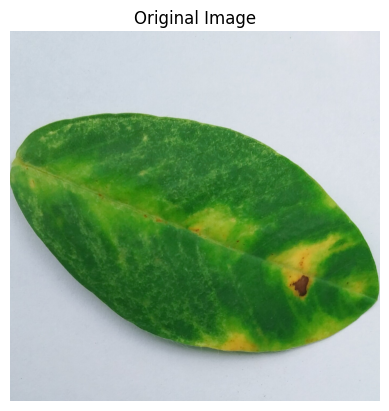

In [8]:
# Convert BGR (OpenCV format) to RGB (display format)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')
plt.show()

**Step 3: Convert Image to Grayscale**

Why? Computers understand intensity (brightness) more easily than color.

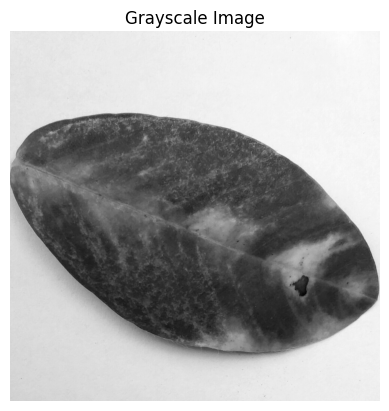

In [9]:
# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

**PART A: POINTS**

Step 4: What is a Point? (Single Pixel)
**bold text**
A point is one pixel at location (x, y).

In [10]:
# Choose a pixel location
x, y = 200, 150

In [11]:
# Read pixel value
pixel_value = gray[y, x]
print("Pixel intensity:", pixel_value)

Pixel intensity: 212


**Step 5: Points as Important Locations (Harris Corner Detection)**

This finds interesting points like corners.

In [12]:
# Convert image to float (required)
gray_float = np.float32(gray)


In [13]:
# Apply Harris corner detector
corners = cv2.cornerHarris(gray_float, blockSize=2, ksize=3, k=0.04)


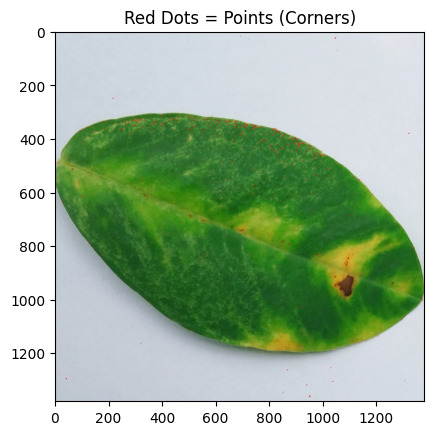

In [19]:
# Copy image to mark corners
corner_image = image_rgb.copy()
corner_image[corners > 0.01 * corners.max()] = [255, 0, 0]

plt.imshow(corner_image)
plt.title("Red Dots = Points (Corners)")
plt.axis('on')
plt.show()

**PART B: PATCHES**

**Step 6: What is a Patch? (Small Region Around a Point)**

A patch gives context around a point.

In [20]:
# Center of patch
cx, cy = 200, 150
patch_size = 25 # half-size

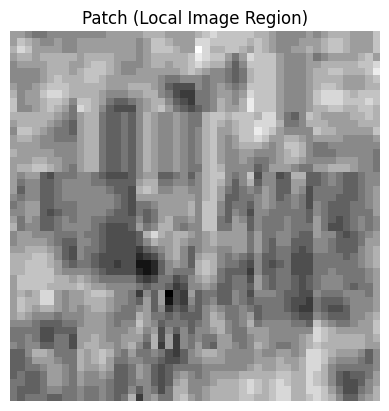

In [21]:
# Extract patch
patch = gray[cy-patch_size:cy+patch_size,
cx-patch_size:cx+patch_size]


plt.imshow(patch, cmap='gray')
plt.title("Patch (Local Image Region)")
plt.axis('off')
plt.show()

**Step 7: Show Where Patch Came From**

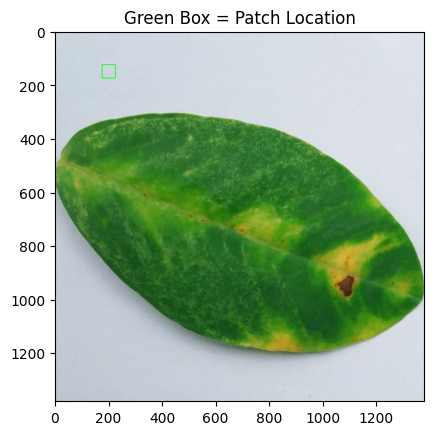

In [25]:
patch_location = image_rgb.copy()


cv2.rectangle(
patch_location,
(cx-patch_size, cy-patch_size),
(cx+patch_size, cy+patch_size),
(0, 255, 0), 2)

plt.imshow(patch_location)
plt.title("Green Box = Patch Location")
plt.axis('on')
plt.show()

**PART C: SIFT (Points + Patches)**

**Step 8: SIFT Feature Detection**

SIFT finds:

Points (keypoints)

Patch-based descriptors

In [28]:
# Create SIFT detector
sift = cv2.SIFT_create()


In [29]:
# Detect keypoints and descriptors
kp_sift, des_sift = sift.detectAndCompute(gray, None)


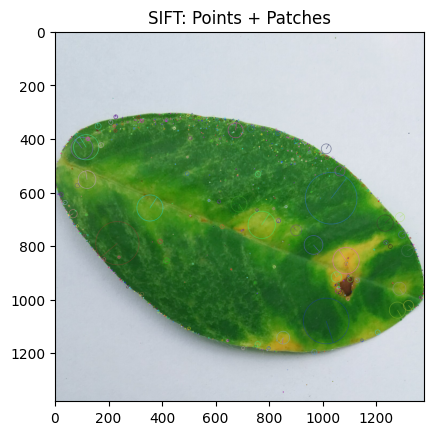

Number of SIFT keypoints: 908


In [31]:
# Draw keypoints
sift_img = cv2.drawKeypoints(
image_rgb,
kp_sift,
None,
flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)


plt.imshow(sift_img)
plt.title("SIFT: Points + Patches")
plt.axis('on')
plt.show()


print("Number of SIFT keypoints:", len(kp_sift))

**PART D: SURF (Concept + Safe Code)**

**Step 9: SURF Explanation**

SURF is similar to SIFT but faster.

In [33]:
try:
    surf = cv2.xfeatures2d.SURF_create(400)
    kp_surf, des_surf = surf.detectAndCompute(gray, None)


    surf_img = cv2.drawKeypoints(
        image_rgb,
        kp_surf,
        None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )


    plt.imshow(surf_img)
    plt.title("SURF Features")
    plt.axis('off')
    plt.show()


except:
    print("SURF not available (non-free module)")

SURF not available (non-free module)


**PART E: CNN (Patch Learning)**

**Step 10: CNN Idea**

CNN does NOT detect points. It slides patches everywhere.

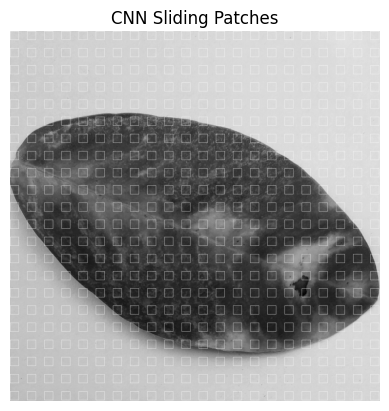

In [35]:
cnn_patch_img = gray.copy()
window = 32


for y in range(0, gray.shape[0]-window, 64):
    for x in range(0, gray.shape[1]-window, 64):
        cv2.rectangle(cnn_patch_img, (x, y), (x+window, y+window), 255, 1)


plt.imshow(cnn_patch_img, cmap='gray')
plt.title("CNN Sliding Patches")
plt.axis('off')
plt.show()

**Step 11: CNN Code (Simple Example)**

In [36]:
import tensorflow as tf
from tensorflow.keras import layers, models



In [37]:
# Prepare input
cnn_input = gray / 255.0
cnn_input = cnn_input.reshape(1, gray.shape[0], gray.shape[1], 1)

In [38]:
# Simple CNN
model = models.Sequential([
layers.Conv2D(8, (3,3), activation='relu'),
layers.MaxPooling2D((2,2)),
layers.Conv2D(16, (3,3), activation='relu'),
layers.MaxPooling2D((2,2))
])


In [39]:
# Run image through CNN
feature_maps = model.predict(cnn_input)


print("CNN feature map shape:", feature_maps.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 604ms/step
CNN feature map shape: (1, 343, 343, 16)


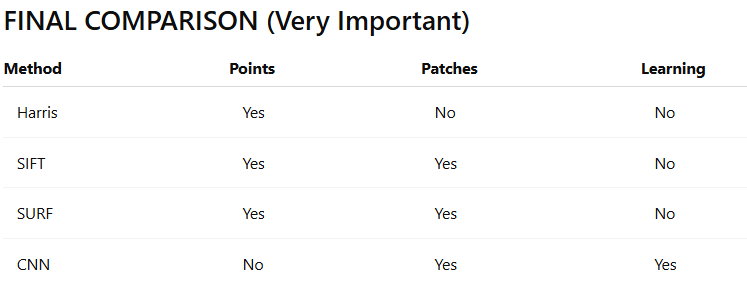

**Points tell where, patches tell what, CNNs learn everything automatically.**